# Mergers using Non-Homologous TARDIS Workflow

In [1]:
from numba import config as nbconfig

nbconfig.DISABLE_JIT = False

In [2]:
from pathlib import Path  # noqa: I001

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from plot_manga import plot_manga_profiles

from tardis.io.configuration.config_reader import Configuration
from tardis.workflows.nonhomologous_tardis_workflow import (
    NonhomologousTARDISWorkflow,
)

from astropy import units as u

Iterations:          0/? [00:00<?, ?it/s]

Packets:             0/? [00:00<?, ?it/s]

Initializing tabulator and plotly panel extensions for widgets to work


Auto-detected VSCode environment


Auto-detected VSCode environment


BokehModel(combine_events=True, render_bundle={'docs_json': {'c3d3c582-e86e-44ec-bdae-72dd5f9ae096': {'version…

BokehModel(combine_events=True, render_bundle={'docs_json': {'3098f8ca-b378-477c-ae55-d05c981fa24e': {'version…

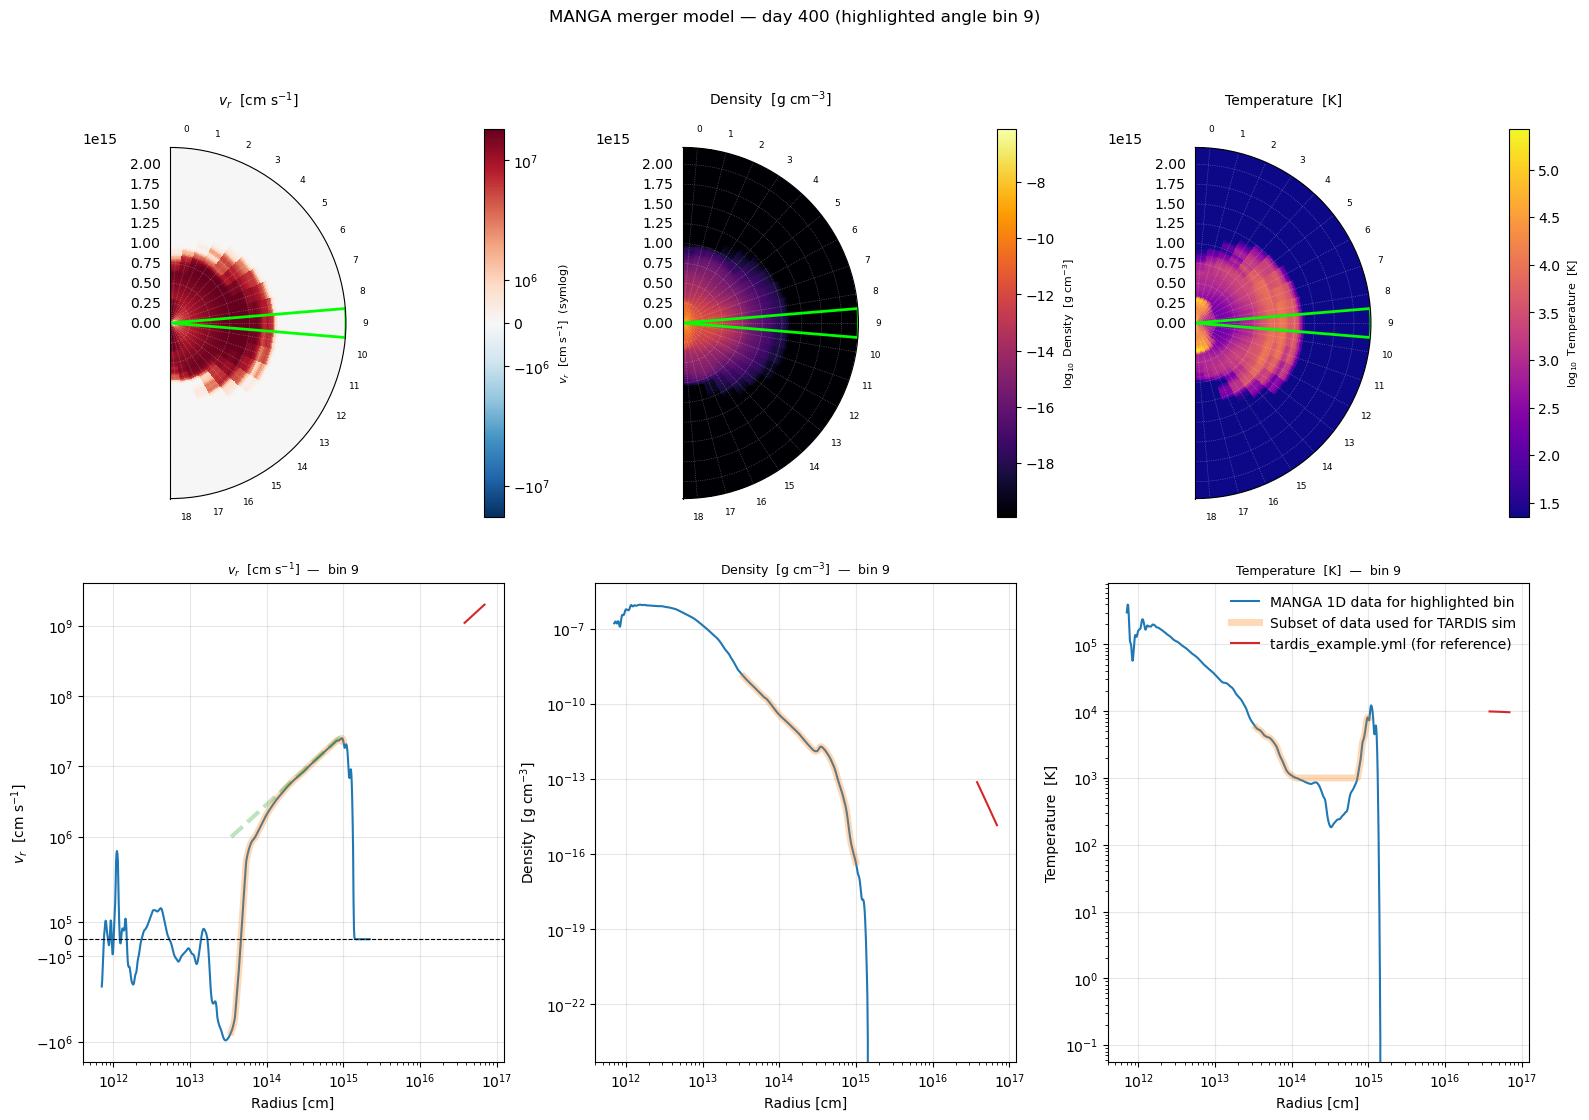

In [3]:
# Load in the MANGA data
time_explosion = 400 # days
fname = f"bins_{time_explosion}days.dat"
nangles = 19
nradii = 599
angle_bin = 9

index = pd.MultiIndex.from_product([range(nangles), range(nradii)], names=['angle bin', 'radius bin'])
data = pd.DataFrame(np.loadtxt(fname, comments=['#', '\n']), columns=["r", "dens", "temp", "v_r"], index=index)

data_1d = data.loc[angle_bin]

#data_1d_cut = data_1d.loc[np.logical_and(data_1d['r'] > 3.5e13, data_1d['r'] < 1e15)]
data_1d_cut = data_1d.loc[np.logical_and(data_1d['r'] > 3.4e13, data_1d['r'] < 1e15)]
#data_1d_cut = data_1d.loc[np.logical_and(data_1d['r'] > 5e13, data_1d['r'] < 1e15)]
nshells = len(data_1d_cut) - 1

# Floor the temperature at 1e3 K
data_1d_cut.loc[data_1d_cut['temp'] < 1e3, "temp"] = 1000.01

# Change selected_bin to highlight a different line of sight
fig = plot_manga_profiles(data, nangles, selected_bin=angle_bin, day=time_explosion)
axes = fig.axes

# Set label for the MANGA data
axes[5].lines[0].set_label('MANGA 1D data for highlighted bin')

# Overplot cut data
axes[3].plot(data_1d_cut['r'], data_1d_cut['v_r'], c="C1", lw=5, alpha=0.3)
axes[4].plot(data_1d_cut['r'], data_1d_cut['dens'], c="C1", lw=5, alpha=0.3)
axes[5].plot(data_1d_cut['r'], data_1d_cut['temp'], c="C1", lw=5, alpha=0.3, label='Subset of data used for TARDIS sim')

# Create homologous data to compare with
data_homologous = data_1d_cut.copy(deep=True)
data_homologous['v_r'] = (data_homologous['r'] / (time_explosion * u.day.to(u.s)))
axes[3].plot(data_homologous['r'], data_homologous['v_r'], c="C2", lw=3, alpha=0.3, linestyle='--')

# Plot fiducial tardis example profiles for comparison
config = Configuration.from_yaml('../../tardis_example.yml')
workflow = NonhomologousTARDISWorkflow(config)
v_fiducial = np.linspace(config.model.structure.velocity.start, config.model.structure.velocity.stop, config.model.structure.velocity.num)
dens_fiducial = workflow.simulation_state.composition.density
temp_fiducial = workflow.simulation_state.t_radiative
r_fiducial = (v_fiducial*time_explosion*u.day).to(u.cm)
axes[3].plot(r_fiducial, v_fiducial.to(u.cm/u.s), c='C3')
axes[4].plot(r_fiducial, dens_fiducial, c='C3')
axes[5].plot(r_fiducial, temp_fiducial, c='C3', label='tardis_example.yml (for reference)')
axes[3].set_xscale('log')
axes[4].set_xscale('log')
axes[5].set_xscale('log')
axes[5].legend(frameon=False)
plt.show()

In [4]:
config_yaml_path = Path("manga_merger_config.yml")
config = Configuration.from_yaml(str(config_yaml_path))

In [5]:
workflow = NonhomologousTARDISWorkflow(config, csvy=True, show_convergence_plots=True)

BokehModel(combine_events=True, render_bundle={'docs_json': {'a37d4d9a-ccc6-4d0a-ad3c-edaa6e85bac8': {'version…

BokehModel(combine_events=True, render_bundle={'docs_json': {'06f515ab-fbce-4cdc-aa09-d33f3d792a3c': {'version…

# Find the Photosphere (tau = 2/3)

Using pure H, calculate the location of the tau=2/3 surface in the MANGA models to make sure we're not too optically thick.

Uses the Rosseland mean opacity (electron scattering + line optical depth), integrated from the outside in, following the same method as in the `v_inner_solver_workflow`.

## Note:

The merger model temperatures can get pretty low, and they're floored at T=1000 K. Hydrogen is fully neutral here, so there won't be any electron number density, meaning the optical depth from electron scattering will be zero for these regions.

In [ ]:
from tardis.workflows.util import get_tau_integ

opacity_states = workflow.solve_opacity()
tau_integ = get_tau_integ(
    workflow.plasma_solver,
    opacity_states['opacity_state'],
    workflow.simulation_state,
)
tau_integ['rosseland'].to(1)

## Just electron scattering opacity

In [ ]:
from astropy import constants as const

# Electron scattering only: kappa_es = n_e * sigma_T
n_e = workflow.plasma_solver.electron_densities.values * u.cm**-3
kappa_es = (n_e * const.sigma_T).to(u.cm**-1)

dr = (workflow.simulation_state.geometry.r_outer - workflow.simulation_state.geometry.r_inner).to(u.cm)
dtau_es = (kappa_es * dr).to(u.dimensionless_unscaled)

# Integrate from outside in (cumsum reversed)
tau_es_integrated = np.cumsum(dtau_es[::-1])[::-1]
print(tau_es_integrated)


## Just a single line

In [ ]:
tau_sobolev = opacity_states['opacity_state'].tau_sobolev

# Pick the line with the largest total tau_sobolev (summed over shells)
line_pos = tau_sobolev.sum(axis=1).values.argmax()
line_id = tau_sobolev.index[line_pos]
line_info = workflow.plasma_solver.atomic_data.lines.iloc[line_pos]

wavelength = (line_info['nu']*u.Hz).to(u.AA, equivalencies=u.spectral())
print(f"Strongest line: {[int(i) for i in line_id]}, wavelength={wavelength:.1f} Å")

tau_sobolev_line = tau_sobolev.iloc[line_pos].values
tau_line_integrated = np.cumsum(tau_sobolev_line[::-1])[::-1]
tau_line_integrated

In [ ]:
plt.plot(r_cm[1:], tau_integ['rosseland'].to(1), label='Rosseland Mean')
plt.plot(r_cm[1:], tau_es_integrated, label='Electron Scattering')
#plt.plot(r_cm[1:], tau_line_integrated, label='Strongest Line')
plt.ylabel(r"$\tau$")
plt.xlabel("r (cm)")
plt.axhline(2./3, c='r', ls='--', label=r'$\tau = 2/3$')
plt.loglog()
plt.legend(frameon=False)

# To do next:

 - Take a typical packet starting frequency and see what maximum red or blue shift it could experience while traveling through the velocity profile from the model
 - Use that to estimate the amount of line opacity it's traveling through - answer the question: "are the packets getting stuck?"

In [6]:
workflow.converged = True
workflow.run()


Shell No.,t_rad,next_t_rad,w,next_w
0,5e+03 K,5.34e+03 K,0.442,0.673
5,5e+03 K,5.34e+03 K,0.315,0.534
10,5e+03 K,5.35e+03 K,0.252,0.441
15,5e+03 K,5.35e+03 K,0.208,0.368
20,5e+03 K,5.35e+03 K,0.174,0.307
25,5e+03 K,5.36e+03 K,0.148,0.257
30,5e+03 K,5.37e+03 K,0.126,0.216
35,5e+03 K,5.37e+03 K,0.108,0.181
40,5e+03 K,5.38e+03 K,0.0927,0.152
45,5e+03 K,5.38e+03 K,0.0799,0.128


    'data': [{'type': 'scatter', 'uid': '1bf54a1b-629a-4d5d-9373-3514d172ab24', …

In [ ]:
workflow.simulation_state.t_radiative

In [ ]:
workflow.simulation_state.t_inner

In [ ]:
spectrum = workflow.spectrum_solver.spectrum_real_packets
spectrum_virtual = workflow.spectrum_solver.spectrum_virtual_packets
spectrum_integrated = workflow.spectrum_solver.spectrum_integrated

<Axes: xlabel='$\\text{Wavelength}\\,[\\mathrm{\\mathring{A}}]$', ylabel='$L_{\\lambda}\\,[\\mathrm{erg\\,s^{-1}\\,\\mathring{A}^{-1}}]$'>

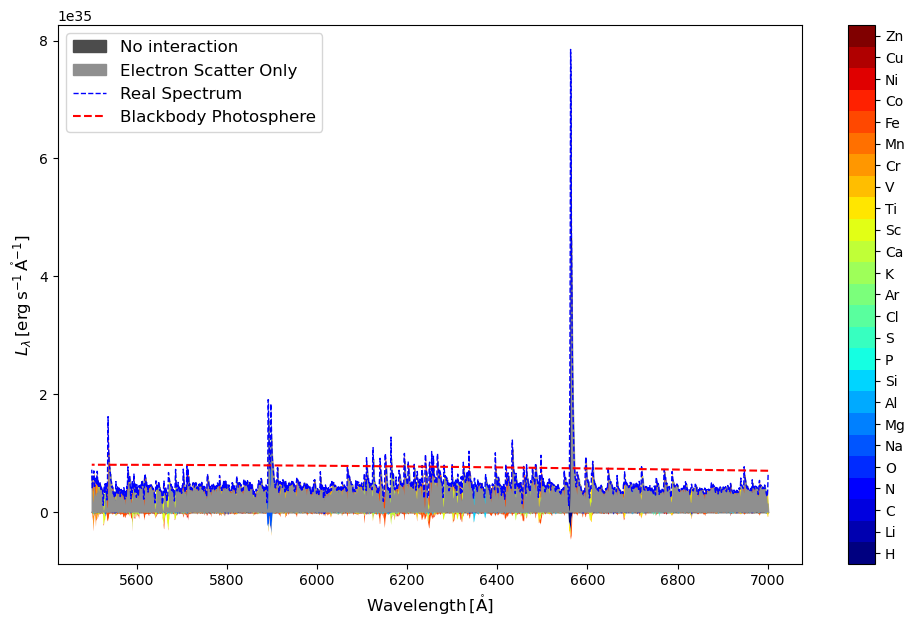

In [7]:
from tardis.visualization import SDECPlotter
plotter = SDECPlotter.from_workflow(workflow)
plotter.generate_plot_mpl(packets_mode="real", nelements=30, packet_wvl_range=[5500, 7000]*u.AA, show_modeled_spectrum=True)

In [8]:
spectrum = workflow.spectrum_solver.spectrum_real_packets
#spectrum_virtual = workflow.spectrum_solver.spectrum_virtual_packets
spectrum_integrated = workflow.spectrum_solver.spectrum_integrated
#hom_spectrum = hom_workflow.spectrum_solver.spectrum_real_packets
#hom_spectrum_virtual = hom_workflow.spectrum_solver.spectrum_virtual_packets
#hom_spectrum_integrated = hom_workflow.spectrum_solver.spectrum_integrated

AssertionError: Frequency grid must be uniform

In [ ]:
%matplotlib inline
plt.figure(figsize=(10, 6.5))

spectrum.plot(label="Normal packets, non-homology", c='C0', alpha=1.0)
#hom_spectrum.plot(label="Normal packets, homology", c='C1', alpha=0.1)

#spectrum_virtual.plot(linewidth=3, c='w', alpha=1.0)
#hom_spectrum_virtual.plot(linewidth=4, c='w', alpha=1.0)
#spectrum_virtual.plot(label="Virtual packets, non-homology", c='C0', alpha=0.35)
#hom_spectrum_virtual.plot(label="Virtual packets, homology", c='C1', alpha=0.35)

#spectrum_integrated.plot(linewidth=3, c='w', alpha=1.0)
#spectrum_integrated.plot(label="Formal Integral, non-homology", c='C0', alpha=1.0)
#hom_spectrum_integrated.plot(label="Formal Integral, homology", c='C1', alpha=1.0, linestyle='--')


plt.xlim(500, 20000)
plt.title("TARDIS example model spectrum")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Luminosity density [erg/s/$\AA$]")
plt.legend()
plt.yscale("log")
plt.show()